In [1]:
import os
import math
import csv
import numpy as np
import pandas as pd
import cv2
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt

from torchvision.transforms import v2
import torchvision.transforms.functional as TF

# Reproducibility (score-neutral; avoids accidental nondeterminism)
torch.manual_seed(42)
np.random.seed(42)



In [2]:
# Kaggle environments are typically offline; avoid pip installs.
# torchinfo is optional; if unavailable, we skip summary.
try:
    from torchinfo import summary

    TORCHINFO_AVAILABLE = True
except Exception:
    TORCHINFO_AVAILABLE = False



In [3]:
# Use Kaggle input folder directly if already extracted; otherwise fall back to unzip into /kaggle/working.
DATA_ROOT_CANDIDATES = [
    "/kaggle/input/denoising-dirty-documents",
    "/kaggle/data/denoising-dirty-documents",
    "/kaggle/working/denoising-dirty-documents",
]
data_root = None
for p in DATA_ROOT_CANDIDATES:
    if os.path.isdir(p) and (
        os.path.isdir(os.path.join(p, "train"))
        or os.path.isfile(os.path.join(p, "train.zip"))
    ):
        data_root = p
        break

if data_root is None:
    raise FileNotFoundError(
        "Could not locate denoising-dirty-documents data root in expected Kaggle paths."
    )

work_extract_root = "/kaggle/working/denoising_data"
os.makedirs(work_extract_root, exist_ok=True)


def ensure_extracted(split_name: str):
    # If folder exists, use it. Else unzip from data_root/{split}.zip to work_extract_root.
    folder = os.path.join(data_root, split_name)
    if os.path.isdir(folder):
        return folder
    zip_path = os.path.join(data_root, f"{split_name}.zip")
    if not os.path.isfile(zip_path):
        raise FileNotFoundError(
            f"Neither folder nor zip found for {split_name}: {folder} / {zip_path}"
        )
    target = work_extract_root
    # Use python zipfile to avoid shell dependency
    import zipfile

    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(target)
    extracted_folder = os.path.join(target, split_name)
    if not os.path.isdir(extracted_folder):
        # some zips might contain nested folder
        # attempt to find the split folder inside target
        for root, dirs, _files in os.walk(target):
            if os.path.basename(root) == split_name:
                extracted_folder = root
                break
    if not os.path.isdir(extracted_folder):
        raise FileNotFoundError(
            f"Extraction succeeded but '{split_name}' folder not found under {target}."
        )
    return extracted_folder


train_dir = ensure_extracted("train")
train_cleaned_dir = ensure_extracted("train_cleaned")
test_dir = ensure_extracted("test")

print("train_dir:", train_dir)
print("train_cleaned_dir:", train_cleaned_dir)
print("test_dir:", test_dir)




train_dir: /kaggle/input/denoising-dirty-documents/train
train_cleaned_dir: /kaggle/input/denoising-dirty-documents/train_cleaned
test_dir: /kaggle/input/denoising-dirty-documents/test


In [4]:
def load_images_from_folder(folder):
    images = []
    for filename in os.listdir(folder):
        if filename.endswith(".png"):
            img_path = os.path.join(folder, filename)
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            images.append(img)
    return images




In [5]:
train_images = load_images_from_folder(train_dir)
train_cleaned_images = load_images_from_folder(train_cleaned_dir)
test_images = load_images_from_folder(test_dir)

print(f"train_images: {len(train_images)}")
print(f"train_cleaned_images: {len(train_cleaned_images)}")
print(f"test_images: {len(test_images)}")



train_images: 115
train_cleaned_images: 115
test_images: 29


In [6]:
train_sizes = [img.shape[:2] for img in train_images]
train_cleaned_sizes = [img.shape[:2] for img in train_cleaned_images]
test_sizes = [img.shape[:2] for img in test_images]

unique_train_sizes = np.unique(train_sizes, axis=0)
unique_train_cleaned_sizes = np.unique(train_cleaned_sizes, axis=0)
unique_test_sizes = np.unique(test_sizes, axis=0)

print(f"train_images unique sizes:\n {unique_train_sizes}")
print(f"train_cleaned_images unique sizes:\n {unique_train_cleaned_sizes}")
print(f"test_images unique sizes:\n {unique_test_sizes}")




train_images unique sizes:
 [[258 540]
 [420 540]]
train_cleaned_images unique sizes:
 [[258 540]
 [420 540]]
test_images unique sizes:
 [[258 540]
 [420 540]]


In [7]:
class PadToSize:
    def __init__(self, target_size):
        self.target_size = target_size  # (H, W)

    def __call__(self, img):
        # img expected shape [C, H, W]
        _, height, width = img.shape
        target_height, target_width = self.target_size

        pad_top = (target_height - height) // 2
        pad_bottom = target_height - height - pad_top
        pad_left = (target_width - width) // 2
        pad_right = target_width - width - pad_left

        return TF.pad(img, [pad_left, pad_top, pad_right, pad_bottom], fill=0)


class Grayscale:
    def __call__(self, img):
        pil_img = TF.to_pil_image(img) if isinstance(img, torch.Tensor) else img
        grayscale_img = pil_img.convert("L")
        return TF.to_tensor(grayscale_img)




In [8]:
train_transforms = v2.Compose(
    [
        v2.ToImage(),
        PadToSize((420, 540)),
        v2.RandomApply([v2.GaussianBlur(kernel_size=3)], p=0.4),
        v2.RandomApply([v2.ColorJitter(brightness=0.3, contrast=0.3)], p=0.5),
        Grayscale(),
        v2.ToDtype(torch.float32, scale=True),
    ]
)

val_transforms = v2.Compose(
    [
        v2.ToImage(),
        PadToSize((420, 540)),
        Grayscale(),
        v2.ToDtype(torch.float32, scale=True),
    ]
)

test_transforms = v2.Compose(
    [
        v2.ToImage(),
        PadToSize((420, 540)),
        Grayscale(),
        v2.ToDtype(torch.float32, scale=True),
    ]
)




In [9]:
class ImageDataset(Dataset):
    def __init__(self, data_dir, transform=None):
        self.data_dir = data_dir
        self.transform = transform
        # IMPORTANT: numeric sort by filename stem to match Kaggle ids and our submission loop
        self.image_files = sorted(
            [
                os.path.join(data_dir, f)
                for f in os.listdir(data_dir)
                if f.endswith(".png")
            ],
            key=lambda x: int(os.path.splitext(os.path.basename(x))[0]),
        )

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_path = self.image_files[idx]
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image


class PairedImageDataset(Dataset):
    def __init__(self, train_files, cleaned_files, transform=None):
        self.train_files = train_files
        self.cleaned_files = cleaned_files
        self.transform = transform

    def __len__(self):
        return len(self.train_files)

    def __getitem__(self, idx):
        train_img = Image.open(self.train_files[idx]).convert("RGB")
        cleaned_img = Image.open(self.cleaned_files[idx]).convert("RGB")
        if self.transform:
            train_img = self.transform(train_img)
            cleaned_img = self.transform(cleaned_img)
        return train_img, cleaned_img




In [10]:
train_files = sorted(
    [os.path.join(train_dir, f) for f in os.listdir(train_dir) if f.endswith(".png")],
    key=lambda x: int(os.path.splitext(os.path.basename(x))[0]),
)
cleaned_files = sorted(
    [
        os.path.join(train_cleaned_dir, f)
        for f in os.listdir(train_cleaned_dir)
        if f.endswith(".png")
    ],
    key=lambda x: int(os.path.splitext(os.path.basename(x))[0]),
)

train_files, val_files, cleaned_train, cleaned_val = train_test_split(
    train_files, cleaned_files, test_size=2 / 9, random_state=42
)

train_dataset = PairedImageDataset(train_files, cleaned_train, train_transforms)
val_dataset = PairedImageDataset(val_files, cleaned_val, val_transforms)
test_dataset = ImageDataset(test_dir, test_transforms)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

print("Train/Val/Test sizes:", len(train_dataset), len(val_dataset), len(test_dataset))



Train/Val/Test sizes: 89 26 29


In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)




device: cuda


In [12]:
class DenoisingAutoencoder(nn.Module):
    def __init__(self):
        super(DenoisingAutoencoder, self).__init__()

        self.enc1 = nn.Sequential(
            nn.Conv2d(1, 1, kernel_size=3, stride=1, padding=1, groups=1, bias=False),
            nn.Conv2d(1, 8, kernel_size=1, stride=1, bias=False),
            nn.BatchNorm2d(8),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )

        self.enc2 = nn.Sequential(
            nn.Conv2d(8, 8, kernel_size=3, stride=1, padding=1, groups=1, bias=False),
            nn.Conv2d(8, 16, kernel_size=1, stride=1, bias=False),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.Dropout(p=0.1),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )

        self.enc3 = nn.Sequential(
            nn.Conv2d(16, 16, kernel_size=3, stride=1, padding=1, groups=1, bias=False),
            nn.Conv2d(16, 32, kernel_size=1, stride=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Dropout(p=0.2),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )

        self.enc4 = nn.Sequential(
            nn.Conv2d(32, 32, kernel_size=3, stride=1, padding=1, groups=1, bias=False),
            nn.Conv2d(32, 64, kernel_size=1, stride=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Dropout(p=0.3),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )

        self.enc5 = nn.Sequential(
            nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1, groups=1, bias=False),
            nn.Conv2d(64, 128, kernel_size=1, stride=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Dropout(p=0.3),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )

        self.dec5 = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=1, stride=1, bias=False),
            nn.ConvTranspose2d(
                64,
                64,
                kernel_size=3,
                stride=2,
                padding=1,
                output_padding=1,
                groups=64,
                bias=False,
            ),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Dropout(p=0.3),
        )

        self.dec4 = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=1, stride=1, bias=False),
            nn.ConvTranspose2d(
                32,
                32,
                kernel_size=3,
                stride=2,
                padding=1,
                output_padding=1,
                groups=32,
                bias=False,
            ),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Dropout(p=0.3),
        )

        self.dec3 = nn.Sequential(
            nn.ConvTranspose2d(32, 16, kernel_size=1, stride=1, bias=False),
            nn.ConvTranspose2d(
                16,
                16,
                kernel_size=3,
                stride=2,
                padding=1,
                output_padding=1,
                groups=16,
                bias=False,
            ),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.Dropout(p=0.2),
        )

        self.dec2 = nn.Sequential(
            nn.ConvTranspose2d(16, 8, kernel_size=1, stride=1, bias=False),
            nn.ConvTranspose2d(
                8,
                8,
                kernel_size=3,
                stride=2,
                padding=1,
                output_padding=1,
                groups=8,
                bias=False,
            ),
            nn.BatchNorm2d(8),
            nn.ReLU(),
            nn.Dropout(p=0.1),
        )

        self.dec1 = nn.Sequential(
            nn.ConvTranspose2d(8, 1, kernel_size=1, stride=1, bias=False),
            nn.ConvTranspose2d(
                1,
                1,
                kernel_size=3,
                stride=2,
                padding=1,
                output_padding=1,
                groups=1,
                bias=False,
            ),
            nn.Sigmoid(),
        )

        self.conv4 = nn.Conv2d(64, 32, kernel_size=1, stride=1, bias=False)
        self.conv5 = nn.Conv2d(128, 64, kernel_size=1, stride=1, bias=False)

    def forward(self, x):
        enc1_out = self.enc1(x)
        enc2_out = self.enc2(enc1_out)
        enc3_out = self.enc3(enc2_out)
        enc4_out = self.enc4(enc3_out)
        enc5_out = self.enc5(enc4_out)

        dec5_out = self.dec5(enc5_out)
        dec5_out = F.interpolate(
            dec5_out, size=(26, 33), mode="bilinear", align_corners=False
        )
        dec5_out = torch.cat([dec5_out, enc4_out], dim=1)
        dec5_out = self.conv5(dec5_out)

        dec4_out = self.dec4(enc4_out)
        dec4_out = F.interpolate(
            dec4_out, size=(52, 67), mode="bilinear", align_corners=False
        )
        dec4_out = torch.cat([dec4_out, enc3_out], dim=1)
        dec4_out = self.conv4(dec4_out)

        dec3_out = self.dec3(dec4_out)
        dec3_out = F.interpolate(
            dec3_out, size=(105, 135), mode="bilinear", align_corners=False
        )

        dec2_out = self.dec2(dec3_out)
        dec2_out = F.interpolate(
            dec2_out, size=(210, 270), mode="bilinear", align_corners=False
        )

        dec1_out = self.dec1(dec2_out)
        dec1_out = F.interpolate(
            dec1_out, size=(420, 540), mode="bilinear", align_corners=False
        )

        outputs = torch.clamp(dec1_out, min=0.001, max=0.999)
        return outputs


model = DenoisingAutoencoder().to(device)



In [13]:
if TORCHINFO_AVAILABLE:
    summary(model, input_size=(16, 1, 420, 540), device=str(device))
else:
    print("torchinfo not available; skipping model summary.")




In [14]:
class RMSELoss(nn.Module):
    def __init__(self):
        super(RMSELoss, self).__init__()

    def forward(self, pred, target):
        return torch.sqrt(F.mse_loss(pred, target))


class HybridLoss(nn.Module):
    def __init__(self, lambda_rmse=0.8, lambda_l1=0.2):
        super(HybridLoss, self).__init__()
        self.lambda_rmse = lambda_rmse
        self.lambda_l1 = lambda_l1
        self.rmse_loss = RMSELoss()
        self.l1_loss = nn.L1Loss()

    def forward(self, pred, target):
        return self.lambda_rmse * self.rmse_loss(
            pred, target
        ) + self.lambda_l1 * self.l1_loss(pred, target)


criterion = HybridLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-2, weight_decay=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=2
)



In [15]:
# Keep core training loop/semantics identical, but it may be slow; user requested no early stopping changes.
epochs = 1000
patience = 5
early_stop_counter = 0
best_val_loss = float("inf")
best_model_state = None

epoch = 0
while epoch < epochs:
    model.train()
    train_loss = 0.0
    train_rmse_loss = 0.0

    for train_images_b, train_cleaned_images_b in train_loader:
        train_images_b, train_cleaned_images_b = train_images_b.to(
            device
        ), train_cleaned_images_b.to(device)
        optimizer.zero_grad()
        outputs = model(train_images_b)
        loss = criterion(outputs, train_cleaned_images_b)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        train_rmse_loss += RMSELoss()(outputs, train_cleaned_images_b).item()

    train_loss /= max(1, len(train_loader))
    train_rmse_loss /= max(1, len(train_loader))
    print(
        f"Epoch [{epoch+1}/{epochs}], Train Loss: {train_loss:.4f}, RMSE Score : {train_rmse_loss:.4f}"
    )

    model.eval()
    val_loss = 0.0
    val_rmse_loss = 0.0
    with torch.no_grad():
        for val_images_b, val_cleaned_images_b in val_loader:
            val_images_b, val_cleaned_images_b = val_images_b.to(
                device
            ), val_cleaned_images_b.to(device)
            outputs = model(val_images_b)
            loss = criterion(outputs, val_cleaned_images_b)
            val_loss += loss.item()
            val_rmse_loss += RMSELoss()(outputs, val_cleaned_images_b).item()

    val_loss /= max(1, len(val_loader))
    val_rmse_loss /= max(1, len(val_loader))

    prev_lr = optimizer.param_groups[0]["lr"]
    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]["lr"]
    if current_lr != prev_lr:
        print(f"Learning Rate updated: {current_lr:.6f}\n")

    if val_loss < best_val_loss:
        print(
            f"New best validation loss: {val_loss:.4f} (Previous: {best_val_loss:.4f}), RMSE Score : {val_rmse_loss:.4f}"
        )
        best_val_loss = val_loss
        best_model_state = {
            k: v.detach().cpu().clone() for k, v in model.state_dict().items()
        }
        early_stop_counter = 0
    else:
        early_stop_counter += 1
        print(
            f"Validation loss increased! Early stopping counter: {early_stop_counter}/{patience}"
        )

    if early_stop_counter >= patience:
        print(f"Early stopping triggered! after {epoch+1} epochs")
        # load best on device
        model.load_state_dict({k: v.to(device) for k, v in best_model_state.items()})
        print(f"Best model loaded with val_loss = {best_val_loss:.4f}")
        break

    epoch += 1

if best_model_state is not None:
    torch.save(best_model_state, "best_model.pth")
    print(f"Best model saved with val_loss = {best_val_loss:.4f}")
else:
    print("No best model was saved.")



Epoch [1/1000], Train Loss: 0.4427, RMSE Score : 0.4464
New best validation loss: 0.4735 (Previous: inf), RMSE Score : 0.4757
Epoch [2/1000], Train Loss: 0.4067, RMSE Score : 0.4111
New best validation loss: 0.4681 (Previous: 0.4735), RMSE Score : 0.4703
Epoch [3/1000], Train Loss: 0.3723, RMSE Score : 0.3767
New best validation loss: 0.4573 (Previous: 0.4681), RMSE Score : 0.4595
Epoch [4/1000], Train Loss: 0.2982, RMSE Score : 0.3046
New best validation loss: 0.4394 (Previous: 0.4573), RMSE Score : 0.4419
Epoch [5/1000], Train Loss: 0.2644, RMSE Score : 0.2727
New best validation loss: 0.4156 (Previous: 0.4394), RMSE Score : 0.4192
Epoch [6/1000], Train Loss: 0.2293, RMSE Score : 0.2417
New best validation loss: 0.3909 (Previous: 0.4156), RMSE Score : 0.3964
Epoch [7/1000], Train Loss: 0.2120, RMSE Score : 0.2260
New best validation loss: 0.3842 (Previous: 0.3909), RMSE Score : 0.3918
Epoch [8/1000], Train Loss: 0.2054, RMSE Score : 0.2206
New best validation loss: 0.3476 (Previous: 

In [16]:
best_model_path = "best_model.pth"
state = torch.load(best_model_path, map_location="cpu")
model.load_state_dict({k: v.to(device) for k, v in state.items()})
model.eval()

with torch.no_grad():
    for images_b in test_loader:
        images_b = images_b.to(device)
        outputs_b = model(images_b)
        break




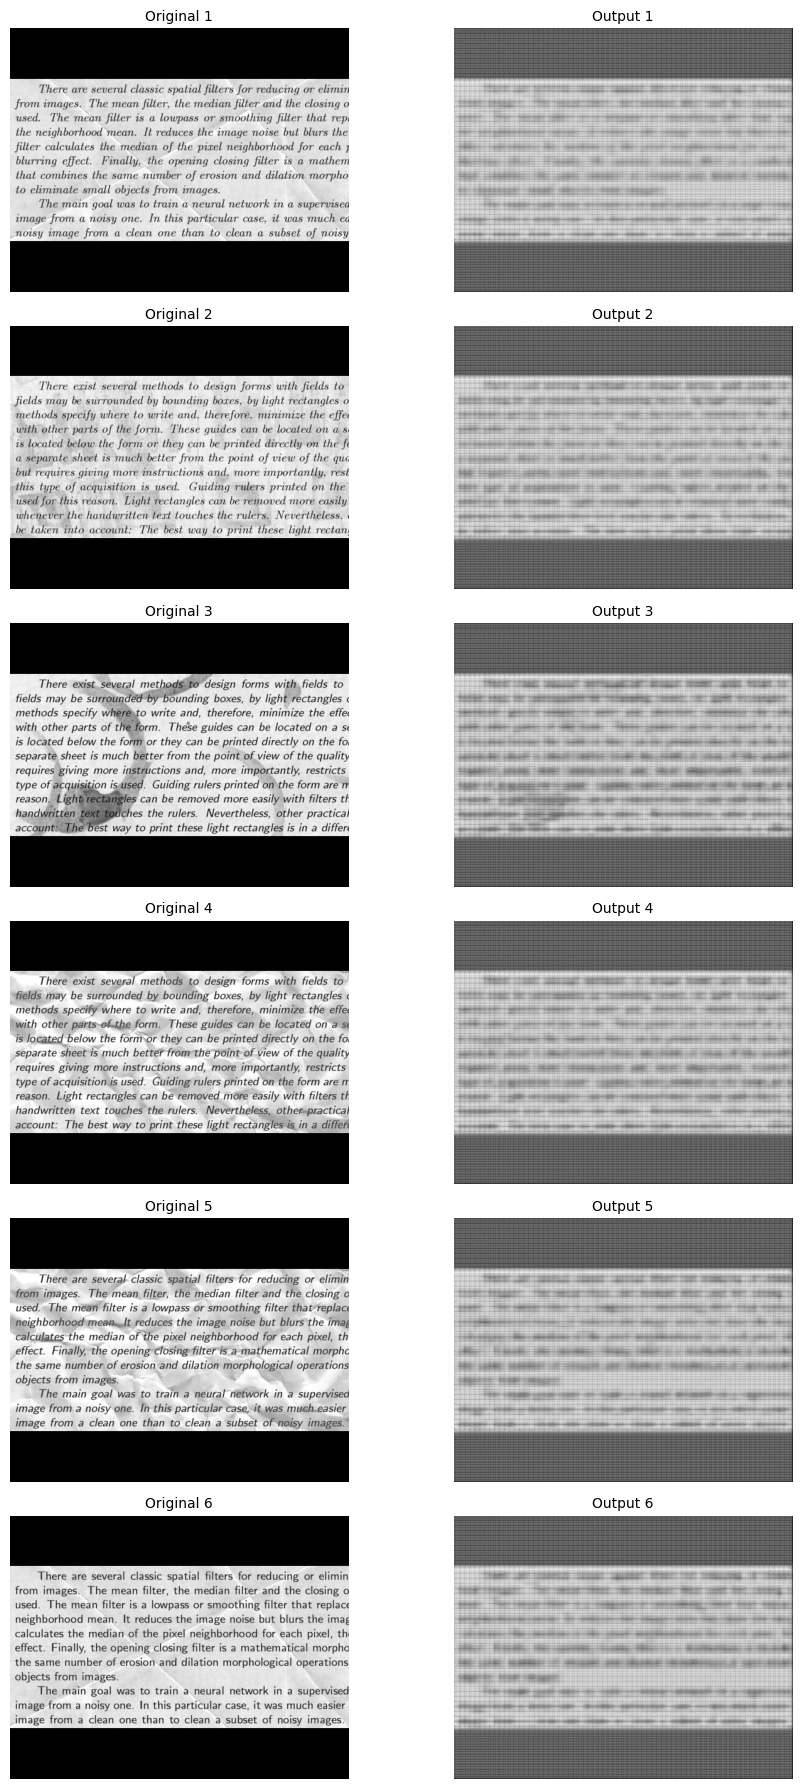

In [17]:
def visualize_images_and_outputs(images, outputs, max_show=6):
    n = min(images.size(0), max_show)
    fig, axes = plt.subplots(n, 2, figsize=(10, n * 3))
    if n == 1:
        axes = np.array([axes])
    for i in range(n):
        axes[i, 0].imshow(images[i].detach().cpu().numpy().squeeze(), cmap="gray")
        axes[i, 0].set_title(f"Original {i + 1}", fontsize=10)
        axes[i, 0].axis("off")

        axes[i, 1].imshow(outputs[i].detach().cpu().numpy().squeeze(), cmap="gray")
        axes[i, 1].set_title(f"Output {i + 1}", fontsize=10)
        axes[i, 1].axis("off")
    plt.tight_layout()
    plt.show()


visualize_images_and_outputs(images_b, outputs_b)



In [18]:
# Full inference (aligned with ImageDataset numeric sort)
model.eval()
all_outputs = []
with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        outputs = model(batch)
        all_outputs.append(outputs.cpu())
all_outputs = torch.cat(all_outputs, dim=0)
print(
    "all_outputs shape:",
    all_outputs.shape,
    "num_test_files:",
    len(test_dataset.image_files),
)



all_outputs shape: torch.Size([29, 1, 420, 540]) num_test_files: 29


In [19]:
# Fix submission generation:
# - Do not hardcode test image count
# - Use the exact same ordered file list as the dataset to align ids with all_outputs indices
target_size = (420, 540)  # (H, W)


def compute_padding(orig_size, target_size):
    orig_height, orig_width = orig_size
    target_height, target_width = target_size
    pad_top = (target_height - orig_height) // 2 if target_height > orig_height else 0
    pad_bottom = (
        target_height - orig_height - pad_top if target_height > orig_height else 0
    )
    pad_left = (target_width - orig_width) // 2 if target_width > orig_width else 0
    pad_right = target_width - orig_width - pad_left if target_width > orig_width else 0
    return pad_top, pad_bottom, pad_left, pad_right


def remove_padding(pred, orig_size, target_size):
    orig_height, orig_width = orig_size
    pad_top, _, pad_left, _ = compute_padding(orig_size, target_size)
    return pred[:, pad_top : pad_top + orig_height, pad_left : pad_left + orig_width]


test_file_paths = (
    test_dataset.image_files
)  # already numeric-sorted and aligned with test_loader
assert (
    len(test_file_paths) == all_outputs.shape[0]
), "Prediction count must match test file count."

submission_data = []
for idx, file_path in enumerate(test_file_paths):
    image_id = os.path.splitext(os.path.basename(file_path))[0]

    orig_img = Image.open(file_path).convert("L")
    orig_width, orig_height = orig_img.size
    orig_size = (orig_height, orig_width)

    pred = all_outputs[idx]  # (1, 420, 540)
    cropped_pred = remove_padding(pred, orig_size, target_size)  # (1, H, W)
    pred_np = cropped_pred.squeeze(0).numpy()

    # Clamp to [0,1] to be safe for metric/input expectations
    pred_np = np.clip(pred_np, 0.0, 1.0)

    for row in range(orig_height):
        # micro-optimization: build ids per row
        base = f"{image_id}_{row+1}_"
        for col in range(orig_width):
            pixel_id = base + str(col + 1)
            submission_data.append((pixel_id, float(pred_np[row, col])))

submission_file = "submission.csv"
with open(submission_file, mode="w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["id", "value"])
    writer.writerows(submission_data)

print(f"Submission file '{submission_file}' created.")
print("Rows:", len(submission_data) + 1)
# Quick sanity check vs sample submission header
sample_path = os.path.join(data_root, "sampleSubmission.csv")
if os.path.isfile(sample_path):
    sample = pd.read_csv(sample_path, nrows=5)
    print("Sample submission head:\n", sample.head())
print("Our submission head:\n", pd.read_csv(submission_file, nrows=5).head())

Submission file 'submission.csv' created.
Rows: 5789881
Sample submission head:
         id  value
0  110_1_1      1
1  110_1_2      1
2  110_1_3      1
3  110_1_4      1
4  110_1_5      1
Our submission head:
       id     value
0  6_1_1  0.800551
1  6_1_2  0.842196
2  6_1_3  0.790255
3  6_1_4  0.848586
4  6_1_5  0.812342
